# IMDB dataset sentiment analysis with recurrent nets

In [1]:
import matplotlib.pyplot as plt  # it is more convenient to type plt than matplotlib.pyplot every time

# the following 'magic' instruction makes the plots appear in the notebook itself
%matplotlib inline  

In [2]:
import numpy as np

In [3]:
import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader 

In [ ]:
!pip install torchtext

In [5]:
from torchtext.data.utils import get_tokenizer

In [6]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print('device', device)
else:
    device = torch.device("cpu")
    print('device', device)

device cuda:0


In [7]:
# tokenization with torchtext
tokenizer = get_tokenizer("basic_english")
tokens = tokenizer("You can now install TorchText using pip!")
tokens
['you', 'can', 'now', 'install', 'torchtext', 'using', 'pip', '!']

['you', 'can', 'now', 'install', 'torchtext', 'using', 'pip', '!']

# Data Preparation

### NOTE: Run this section only once to understand the preprocessing as it takes a while. A file called `imdb_raw_and_coded_data.pickle` is created and saved with all the pre-processed data.So next time you run just skip to [here](#Start-here!--Load-the-Processed-Data).

### You can also download the file called  `imdb_raw_and_coded_data.pickle` from moodle, which contains the results of the preprocessing. But do go through this section at least once. Then skip on down to [here](#Start-here!--Load-the-Processed-Data).

The pickle file (Python serialization is called pickling) may possibly not load if you are using a different version of python, in which case you can start by downloading the aclImdb dataset from the address suggested below, and then processing it.  This may take some time if your disk access is slow. 

In [8]:
# this code asumues you have downloaded the aclimdb dataset
# of 25000 film reviews from IMDB, labelled with positive (1) or 
# negative (0) sentiment, and that you have unzipped it into a 
# directory tree, starting from the directory aclImdb

# the dataset can be downloaded from ai.stanford.edu/~amaas/data/sentiment/ and other places

# the code below opens and reads 25000 files, and can be slow on some machines

import os

imdb_dir = 'aclImdb'
train_dir = os.path.join(imdb_dir, 'train')

labels = []
texts = []

n_processed =  0

for label_type in ['neg', 'pos']:
    dir_name = os.path.join(train_dir, label_type)
    for fname in os.listdir(dir_name):
        if fname[-4:] == '.txt':
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
            if label_type == 'neg':
                labels.append(0)
            else:
                labels.append(1)
            n_processed += 1
            if n_processed%1000 == 0:
                print(n_processed)
                     

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000


In [9]:
len(texts)

25000

(array([12500.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 12500.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

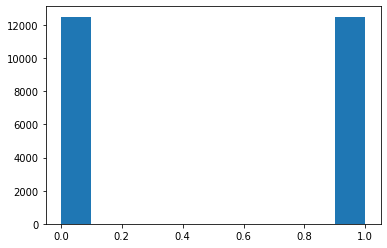

In [10]:
# see the label distribution
plt.hist(labels)

In [11]:
from torchtext.vocab import build_vocab_from_iterator

# function to tokenize the text
def yield_tokens(data_iter):
    for text in data_iter:
        yield tokenizer(text)
        
data_iter = iter(texts)
# we are ignoring words which do not appear very frequently, that is words that appear less than 30 times. 
# Feel free to change this to see how it affects your results.
# Generate sequences from the tokens.
vocab = build_vocab_from_iterator(yield_tokens(data_iter), min_freq=30, specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

In [12]:
len(vocab)

10235

In [13]:
# example tokenization and conversion to sequence
print(texts[1])
vocab(tokenizer(texts[1]))

A well put together entry in the serial killer genre that unfortunately gets mired down in its own pretentiousness to be really satisfying. Willem Dafoe is superb as a NYC detective trying to track down what appears to be a copycat using the same Renaissance art-related killing techniques used in a series of murders he solved years earlier. Scott Speedman is Dafoe's junior partner and they have pretty good chemistry (at least for a while). Other characters pop up to conveniently tie the two cases together. Clea Duval is the friend of an earlier victim and Peter Stormare is some sort of art broker/mentor to Dafoe...that's a bit hard to take, although Stormare is, of course, never dull. The film's ending is particularly disappointing. Look fast for Deborah Harry as Dafoe's less than forthcoming neighbor.


[5,
 79,
 276,
 300,
 3213,
 11,
 1,
 1411,
 450,
 523,
 14,
 470,
 215,
 0,
 194,
 11,
 98,
 207,
 0,
 7,
 33,
 71,
 2314,
 2,
 9794,
 7221,
 9,
 889,
 17,
 5,
 4788,
 1241,
 269,
 7,
 1406,
 194,
 53,
 722,
 7,
 33,
 5,
 0,
 758,
 1,
 177,
 5451,
 0,
 877,
 3321,
 348,
 11,
 5,
 209,
 6,
 1461,
 29,
 8091,
 160,
 895,
 2,
 1008,
 0,
 9,
 7221,
 8,
 15,
 4699,
 1905,
 4,
 38,
 32,
 189,
 56,
 1151,
 24,
 37,
 225,
 18,
 5,
 142,
 23,
 2,
 87,
 110,
 1882,
 65,
 7,
 6660,
 4670,
 1,
 114,
 2899,
 300,
 2,
 0,
 0,
 9,
 1,
 452,
 6,
 40,
 895,
 1320,
 4,
 778,
 0,
 9,
 55,
 440,
 6,
 525,
 0,
 7,
 7221,
 2,
 2,
 2,
 14,
 8,
 15,
 5,
 229,
 272,
 7,
 198,
 3,
 263,
 0,
 9,
 3,
 6,
 266,
 3,
 118,
 742,
 2,
 1,
 22,
 8,
 15,
 280,
 9,
 570,
 1294,
 2,
 173,
 824,
 18,
 8734,
 1210,
 17,
 7221,
 8,
 15,
 335,
 78,
 0,
 3298,
 2]

In [14]:
from torch.nn.utils.rnn import pad_sequence

maxlen = 500                                           
training_samples = 20000
validation_samples = 5000
max_words = 10000                                      

sequences = []

# pad the sequences so all have the same length
for text in texts:
    sequences.append(torch.tensor(vocab(tokenizer(text)[0:maxlen])))

data = pad_sequence(sequences, True, padding_value=0)

labels = torch.tensor(labels)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)

x_train = data[:training_samples]
y_train = labels[:training_samples]
x_val = data[training_samples: training_samples + validation_samples]
y_val = labels[training_samples: training_samples + validation_samples]

Shape of data tensor: torch.Size([25000, 500])
Shape of label tensor: torch.Size([25000])


In [15]:
x_train.shape,y_train.shape

(torch.Size([20000, 500]), torch.Size([20000]))

(array([12500.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  7500.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

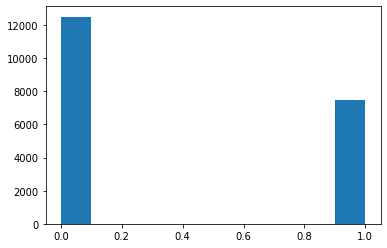

In [16]:
# see the train label distribution
plt.hist(y_train.numpy())

In [17]:
x_val.shape,y_val.shape

(torch.Size([5000, 500]), torch.Size([5000]))

(array([   0.,    0.,    0.,    0.,    0., 5000.,    0.,    0.,    0.,
           0.]),
 array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5]),
 <BarContainer object of 10 artists>)

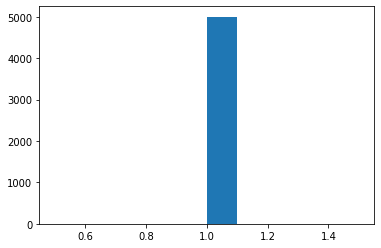

In [18]:
# see the validation label distribution
plt.hist(y_val.numpy())

In [19]:
# DO NOT RUN this unless you have just processed all the data and newly created these variables
import pickle
pickle.dump( (texts, labels, vocab, x_train, y_train, x_val, y_val, tokenizer), 
            open("imdb_raw_and_coded_data.pickle","wb"))


# Start here!  Load the Processed Data

In [68]:
import pickle  # this is Python's seralizer package

# this is a pickled file of the variables that you need, which I made earlier :) 
(texts, labels, vocab, x_train, y_train, x_val, y_val, tokenizer ) = pickle.load(open("imdb_raw_and_coded_data.pickle","rb"))

max_words = len(vocab)# the maximum number of words that were allowed in the dictionary. 
max_words

10235

Now have a look at the data: I should warn you that some objects are quite large. 
    
* `texts` is a python list of reviews.  Read some!  
* `labels` is a vector of sentiments, 0 for negative, 1 for positive. Check some. Do you agree? 
* `vocab` contains the processed word dictionary
* `x_train`, `x_val` are numpy arrays of tokenized reviews; `x_train` is the first 20000 reviews, `x_val` the rest. They have been cut to 500 words, and padded with zeros from the start if they are too short. You should check that the reviews and the texts correspond -- check that texts[17] and x_train[17] are the same review, using `word_index` to convert some words to their index numbers. 

***DO NOT BE TEMPTED TO SKIP THIS - MAKE SURE YOU UNDERSTAND THE DATA!! ***

## Making up your own reviews to test the models :) 

In [69]:
# this is a function that converts reviews that you can write to test the system into coded vectors that you can 
# supply to the model, and get predictions for. 

# note that is accesses tokenizer as a global variable 
maxlen = 500
def encode_my_reviews( list_of_my_reviews):
    my_sequences = []
    for review in list_of_my_reviews:
        my_sequences.append(torch.tensor(vocab(tokenizer(review)[0:maxlen])))
    my_data = pad_sequence(my_sequences, True, padding_value=0)
    tmp_data = torch.zeros(my_data.shape[0], maxlen).type(torch.int64)
    for i, data in enumerate(my_data):
        tmp_data[i,0:data.shape[0]] = my_data[i,0:data.shape[0]]
    return tmp_data

In [70]:
# all you have to do is to construct a list of strings, each string being a review. You can 
# then use model.predict(encode_my_reviews(my_reviews)) to see what the model predicts about them. 
# Try to fool the models you construct! 
# How much do they really understand? 

my_reviews = [ "This was the worst film I have ever seen, and I fell asleep immediately.", 
              "This was the best film I have ever seen in my life. Truly wonderful from start to finish."]

In [71]:
my_reviews_coded = encode_my_reviews(my_reviews)
my_reviews_coded.shape

torch.Size([2, 500])

In [73]:
# let's see what the encoded reviews actually look like. 
my_reviews_coded

tensor([[  13,   16,    1,  252,   22,   12,   32,  130,  116,    3,    4,   12,
         1534, 2309, 1199,    2,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,  

In [74]:
# create data loaders for train and validation data

train_data = TensorDataset( torch.LongTensor( x_train ), torch.LongTensor( y_train ))
test_data = TensorDataset( torch.LongTensor( x_val ), torch.LongTensor( y_val ))

batch_size = 128

train_loader = DataLoader( train_data, shuffle=True, batch_size= batch_size )
test_loader = DataLoader( test_data, shuffle=True, batch_size = batch_size ) # we don't really need to shuffle this

## Define the RNN model

In [75]:
# Define a sequence model where you can select different kinds of rnn models such as simple RNN and LSTM.
# You can extend it to include other rnn models such as bidirectional LSTM and GRU.
class SentimentAnalyser(nn.Module):

    def __init__(self, model_type, embedding_dim, hidden_dim, vocab_size, num_classes):

        super(SentimentAnalyser, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)

        # The rnn models take word embeddings as inputs, and output hidden states
        # with dimensionality hidden_dim.
        if model_type == 'rnn':
            self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_dim, batch_first=True)
        else:
            self.rnn = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, batch_first=True)

        # The linear layer that maps from hidden state space to classes
        self.hidden = nn.Linear(hidden_dim, num_classes)
        
        self.sigmoid = nn.Sigmoid()

    def forward(self, sentence):
        bs = sentence.shape[0]
        embeds = self.word_embeddings(sentence)
        lstm_out, _ = self.rnn(embeds)
        lstm_out = lstm_out.contiguous().view(-1, self.hidden_dim )
        out = self.hidden(lstm_out)
        out = self.sigmoid( out )
        out = out.view( bs, -1 )
        out = out[:,-1]
        return out

In [76]:
# compute the accuracy of the model predictions
def accuracy(outputs, targets):
    pred_labels = torch.zeros(len(outputs)).to(device)
    ones_index = torch.where(outputs > 0.5)[0]
    pred_labels[ones_index] = 1.0
    return torch.sum(pred_labels==targets.float())/float(len(pred_labels))

In [95]:
# training the model

def train_model(model):
    epochs = 30
    history = {'loss':[], 'val_loss':[], 'accuracy':[], 'val_accuracy':[]}
    for i in range( epochs ):

        running_loss = 0
        num_batches = 0 
        training_accuracy = 0

        for inputs, targets in train_loader: 
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            num_batches += 1 

            model.zero_grad()

            output = model( inputs )
            loss = criterion(output, targets.float())
            loss.backward()

            # compute training loss
            running_loss += loss

            optimizer.step()

            # compute training accuracy
            training_accuracy += accuracy(output, targets)

        running_loss = running_loss.item()/num_batches  
        training_accuracy = training_accuracy.item()/num_batches

        val_accuracy = 0
        val_loss = 0
        num_batches = 0 

        # compute test loss and accuracy
        for test_inputs, test_labels in test_loader:
            test_inputs, test_labels = test_inputs.to(device, non_blocking=True), test_labels.to(device, non_blocking=True)
            num_batches += 1

            test_outputs = model(test_inputs)
            # print(test_outputs,test_labels,'\n')
            val_loss += criterion(test_outputs, test_labels.float())
            val_accuracy += accuracy(test_outputs, test_labels)

        val_accuracy = val_accuracy.item()/num_batches 
        val_loss = val_loss.item()/num_batches

        history['loss'].append(running_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(training_accuracy)
        history['val_accuracy'].append(val_accuracy)

        print('epoch',i,'loss', "{:.2f}".format(running_loss),'training accuracy', "{:.2f}".format(training_accuracy), 'val accuracy', "{:.2f}".format(val_accuracy))
    return model, history

In [78]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.ylim(0,1)

    plt.figure()

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

## Build and train a simple RNN model

In [103]:
num_classes = len(torch.unique(y_train))
vocab_size = len(vocab)+1
embed_dim = 64
hidden_dim = 64

model_rnn = SentimentAnalyser('rnn', embed_dim, hidden_dim, vocab_size, num_classes).to(device)

In [104]:
lr = 0.001
criterion = nn.BCELoss()
optimizer = torch.optim.RMSprop( model_rnn.parameters(), lr=lr, momentum=0.9 )

In [105]:
model_rnn, history_rnn = train_model(model_rnn)

epoch 0 loss 0.68 training accuracy 0.60 val accuracy 0.02
epoch 1 loss 0.67 training accuracy 0.62 val accuracy 0.02
epoch 2 loss 0.67 training accuracy 0.62 val accuracy 0.01
epoch 3 loss 0.67 training accuracy 0.62 val accuracy 0.02
epoch 4 loss 0.66 training accuracy 0.62 val accuracy 0.02
epoch 5 loss 0.66 training accuracy 0.62 val accuracy 0.01
epoch 6 loss 0.67 training accuracy 0.62 val accuracy 0.02
epoch 7 loss 0.66 training accuracy 0.63 val accuracy 0.03
epoch 8 loss 0.66 training accuracy 0.63 val accuracy 0.04
epoch 9 loss 0.66 training accuracy 0.64 val accuracy 0.04
epoch 10 loss 0.66 training accuracy 0.64 val accuracy 0.04
epoch 11 loss 0.66 training accuracy 0.64 val accuracy 0.04
epoch 12 loss 0.65 training accuracy 0.64 val accuracy 0.04
epoch 13 loss 0.65 training accuracy 0.64 val accuracy 0.04
epoch 14 loss 0.65 training accuracy 0.64 val accuracy 0.05
epoch 15 loss 0.65 training accuracy 0.64 val accuracy 0.04
epoch 16 loss 0.64 training accuracy 0.64 val accu

In [111]:
pred_labels = model_rnn(my_reviews_coded.to(device)).cpu().detach().numpy()
for review, pred_label in zip(my_reviews, pred_labels):
    print(review,': ', pred_label)
    
print("\nWe see from the above result that the simple RNN performs poorly on classifying the reviews.")

This was the worst film I have ever seen, and I fell asleep immediately. :  0.41580573
This was the best film I have ever seen in my life. Truly wonderful from start to finish. :  0.41580573

We see from the above result that the simple RNN performs poorly on classifying the reviews.


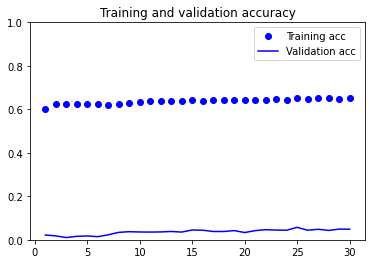

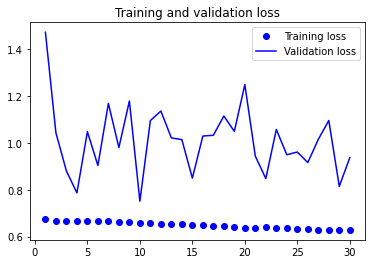

In [107]:
plot_history(history_rnn)

## Build and train a LSTM model

In [98]:
num_classes = len(torch.unique(y_train))
vocab_size = len(vocab)+1
embed_dim = 64
hidden_dim = 64

model_lstm = SentimentAnalyser('lstm', embed_dim, hidden_dim, vocab_size, num_classes).to(device)

In [99]:
lr = 0.001
criterion = nn.BCELoss()
optimizer = torch.optim.RMSprop( model_lstm.parameters(), lr=lr, momentum=0.9 )

In [100]:
model_lstm, history_lstm = train_model(model_lstm)

epoch 0 loss 0.66 training accuracy 0.62 val accuracy 0.00
epoch 1 loss 0.66 training accuracy 0.63 val accuracy 0.03
epoch 2 loss 0.64 training accuracy 0.65 val accuracy 0.05
epoch 3 loss 0.53 training accuracy 0.74 val accuracy 0.56
epoch 4 loss 0.39 training accuracy 0.84 val accuracy 0.60
epoch 5 loss 0.30 training accuracy 0.88 val accuracy 0.71
epoch 6 loss 0.23 training accuracy 0.91 val accuracy 0.79
epoch 7 loss 0.19 training accuracy 0.93 val accuracy 0.76
epoch 8 loss 0.16 training accuracy 0.94 val accuracy 0.84
epoch 9 loss 0.15 training accuracy 0.95 val accuracy 0.81
epoch 10 loss 0.11 training accuracy 0.96 val accuracy 0.71
epoch 11 loss 0.10 training accuracy 0.97 val accuracy 0.84
epoch 12 loss 0.09 training accuracy 0.97 val accuracy 0.75
epoch 13 loss 0.08 training accuracy 0.97 val accuracy 0.81
epoch 14 loss 0.07 training accuracy 0.98 val accuracy 0.72
epoch 15 loss 0.06 training accuracy 0.98 val accuracy 0.75
epoch 16 loss 0.06 training accuracy 0.98 val accu

In [112]:
pred_labels = model_lstm(my_reviews_coded.to(device)).cpu().detach().numpy()
for review, pred_label in zip(my_reviews, pred_labels):
    print(review,': ', pred_label)
    
print("\nWe see from the above result that the LSTM performs well on classifying the reviews.")

This was the worst film I have ever seen, and I fell asleep immediately. :  7.062721e-05
This was the best film I have ever seen in my life. Truly wonderful from start to finish. :  0.9992932

We see from the above result that the LSTM performs well on classifying the reviews.


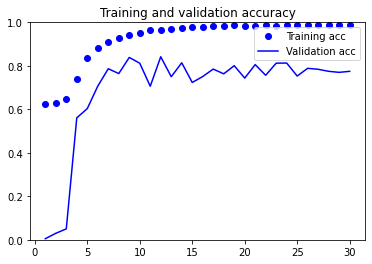

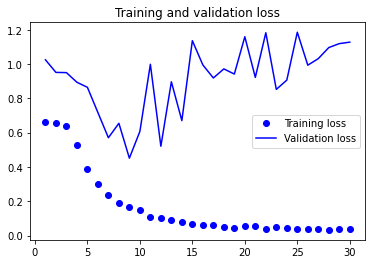

In [102]:
plot_history(history_lstm)

### Exercise
1. Note that the train and validation set labels are not balanced. Try to create a balanced train and test dataset and see how that affects your model loss and accuracy. 
2. Try using larger embedinng and hidden size. 
3. Try other RNNs such as bidirectional lstm and GRU.